# Week 5 Day 4 Lab

### Problem 1
Suppose 

$$\frac{dy}{dt}=1.2y.$$

instead of .5 from lecture. Solve again.

How does the graph change?



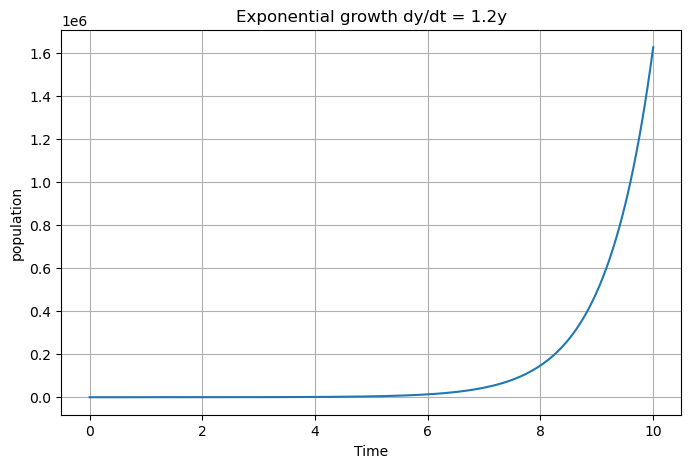

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def model(t,y):
    return 1.2*y

solution = solve_ivp(model, [0,10],[10],dense_output=True)
t = np.linspace(0,10,200)
y = solution.sol(t)[0]

plt.figure(figsize=(8,5))
plt.plot(t,y)
plt.xlabel("Time")
plt.ylabel("population")
plt.title("Exponential growth dy/dt = 1.2y")
plt.grid()
plt.show()
# the below plot grows faster than the lecture example because 1.2 used here is bigger than 0.5

### Problem 2

Solve

$$
\frac{dy}{dt}=3y
$$

with
$$
y(0)=2.
$$

Plot the solution.



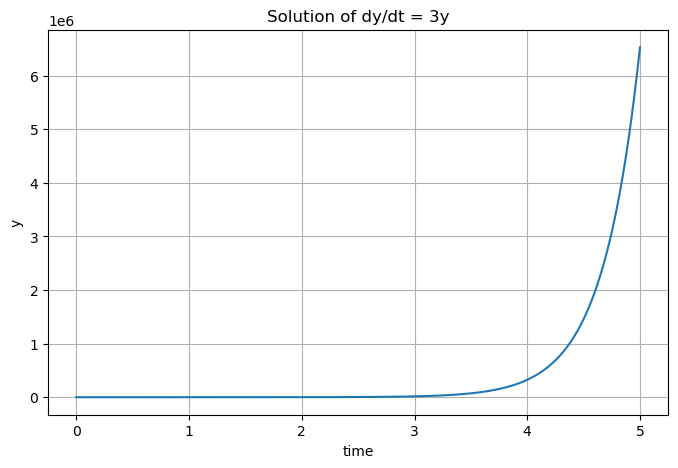

In [4]:
def model2(t, y):
    return 3*y

solution2 = solve_ivp(model2,[0, 5],[2], dense_output=True)
t = np.linspace(0,5,200)
y = solution2.sol(t)[0]

plt.figure(figsize=(8,5))
plt.plot(t,y)
plt.xlabel("time")
plt.ylabel("y")
plt.title("Solution of dy/dt = 3y")
plt.grid()
plt.show() # this grows very fast because the rate is 3y

### Problem 3

Solve

$$
\frac{dy}{dt}
=
-0.4y
$$

starting from

$$
y(0)=50.
$$


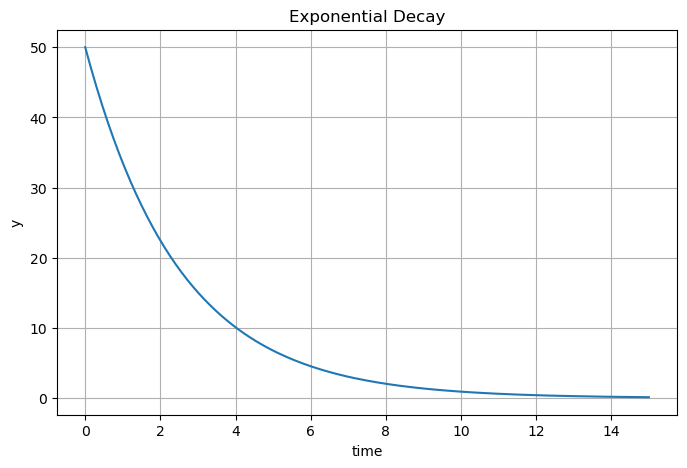

In [8]:
def decay(t,y):
    return -0.4*y

solution3 = solve_ivp(decay,[0,15],[50],dense_output=True)
t = np.linspace(0,15,200)
y = solution3.sol(t)[0]

plt.figure(figsize=(8,5))
plt.plot(t,y)
plt.xlabel("time")
plt.ylabel("y")
plt.title("Exponential Decay")
plt.grid()
plt.show()# this starts at 50 and then decays toward 0 so it decreases because the derivative is negative

## Problem 4

Modify the logistic model by ranging $K$ from 0 to 50 with 100 slices.

How does the solution change?


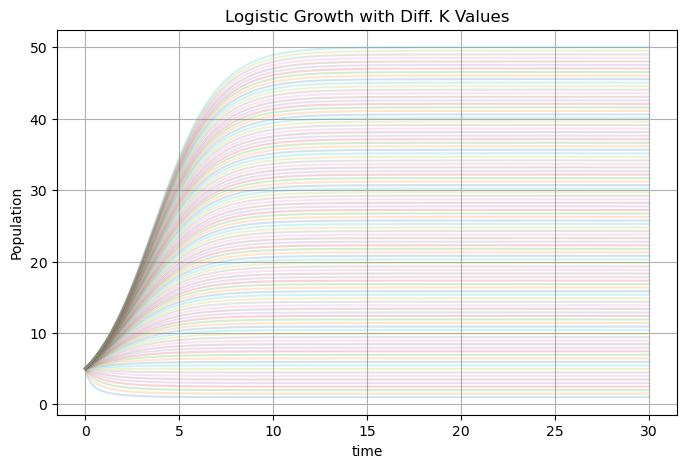

In [6]:
r = 0.6
initial = [5]
K_values = np.linspace(1,50,100)# K = 0 does not work because it needs to divide by K
t = np.linspace(0,30,300)
plt.figure(figsize=(8,5))

for K in K_values:
    def logistic(t,y):
        return r*y*(1 - y/K)
        
    solution = solve_ivp(logistic,[0,30],initial,dense_output=True)
    plt.plot(t, solution.sol(t)[0],alpha=0.2)

plt.xlabel("time")
plt.ylabel("Population")
plt.title("Logistic Growth with Diff. K Values")
plt.grid()
plt.show() # larger K makes the population level off at a higher value so K is the carrying capacity

## Problem 5

Create your own model.

Ideas include

- Predator-prey model
- Cooling of coffee
- Disease spread
- Population growth
- Bank account with continuous interest

Model the system using a differential equation and solve it with `solve_ivp()`

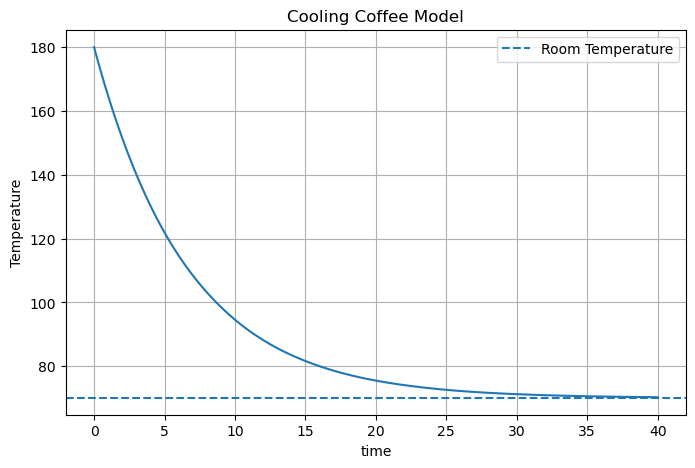

In [7]:
# cooling coffee model, classic thermal dynamics problem.
room_temp = 70
k = 0.15

def coffee(t, y):
    return -k*(y-room_temp)

solution5 = solve_ivp(coffee,[0,40],[180],dense_output=True)
t = np.linspace(0,40,200)
y = solution5.sol(t)[0]

plt.figure(figsize=(8,5))
plt.plot(t,y)
plt.axhline(room_temp,linestyle="--",label="Room Temperature")
plt.xlabel("time")
plt.ylabel("Temperature")
plt.title("Cooling Coffee Model")
plt.legend()
plt.grid()
plt.show()

# the coffee cools down toward room temperature, so it starts at 180 and gets closer to 70 over time